# Build Tool & Language Distribution

Distribution of build tools and versions across successfully built repositories.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# Load sample data — replace with your own query results
summary = pd.read_csv("../../samples/build-tool-summary.csv")
versions = pd.read_csv("../../samples/build-tool-versions.csv")

In [ ]:
# Build tool distribution — donut chart
import numpy as np

colors = ["#283AF7", "#7C3AED", "#E93D82", "#00CFF3", "#85FE99", "#FFBF81"]

total = summary["repos"].sum()
legend_labels = [f"{row['build_tool']} — {row['repos']} repos ({row['repos'] / total * 100:.1f}%)"
                 for _, row in summary.iterrows()]

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts = ax.pie(
    summary["repos"], labels=None,
    colors=colors[:len(summary)],
    startangle=53,
    wedgeprops=dict(width=0.4))

# Add build tool names on the slices
for i, (wedge, name) in enumerate(zip(wedges, summary["build_tool"])):
    ang = (wedge.theta2 + wedge.theta1) / 2
    r = 0.8  # middle of the donut ring
    x = r * np.cos(np.radians(ang))
    y = r * np.sin(np.radians(ang))
    pct = summary["repos"].iloc[i] / total * 100
    if pct >= 5:
        ax.text(x, y, name, ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0.5),
          fontsize=10, frameon=False)

ax.set_title("Build Tool Distribution (by Repos)", color="black", fontsize=14)
plt.tight_layout()
plt.show()

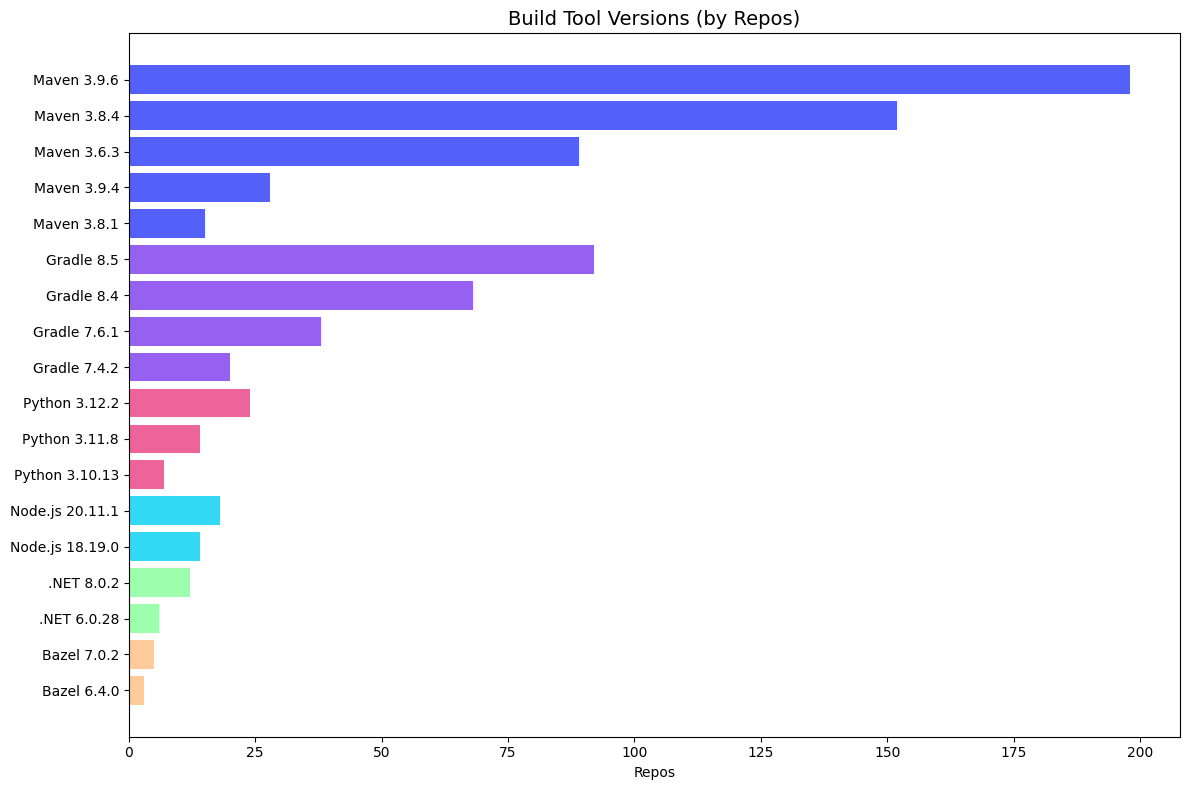

In [44]:
# Version breakdown — horizontal bar chart
tool_colors = {
    "Maven": "#283AF7", "Gradle": "#7C3AED", "Python": "#E93D82",
    "Node.js": "#00CFF3", ".NET": "#85FE99", "Bazel": "#FFBF81"
}

fig, ax = plt.subplots(figsize=(12, 8))

labels = [f"{row['build_tool']} {row['tool_version']}" for _, row in versions.iterrows()]
bar_colors = [tool_colors.get(row["build_tool"], "#999999") for _, row in versions.iterrows()]

y = range(len(versions))
ax.barh(y, versions["repos"], color=bar_colors, alpha=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Repos", color="black")
ax.set_title("Build Tool Versions (by Repos)", color="black", fontsize=14)
ax.tick_params(axis="both", labelcolor="black")

plt.tight_layout()
plt.show()